In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib
import sys
from time import time
from scipy.optimize import minimize, differential_evolution

In [11]:
# specific_name = "qiskit_codes"
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/data/kyiv/14/power_broadening (narrowing)"
which_plots = 2

if which_plots == 0:
    folders = [f"{folder}/lz1_pulses/2024-12-29",
               f"{folder}/lz4_pulses/2024-12-30",
               f"{folder}/lz8_pulses/2024-12-30",
               f"{folder}/lz1_pulses/sim"]
elif which_plots == 1:
    folders = [f"{folder}/ae1_pulses/2024-12-30",
               f"{folder}/ae4_pulses/2024-12-30",
               f"{folder}/ae8_pulses/2024-12-30",
               f"{folder}/ae8_pulses/sim"]
elif which_plots == 2:
    folders = [f"{folder}/hae1_pulses/2024-12-30",
               f"{folder}/hae4_pulses/2024-12-30",
               f"{folder}/hae8_pulses/2024-12-30",
               f"{folder}/hae8_pulses/sim"]
times = []
for folder in folders:
    times_folder = [folder + '/' + os.listdir(folder)[-1]]
    times.extend(times_folder)
print(times)


['C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/hae1_pulses/2024-12-30/222124', 'C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/hae4_pulses/2024-12-30/223735', 'C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/hae8_pulses/2024-12-30/224842', 'C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/hae8_pulses/sim/999999']


In [12]:
if which_plots == 1:
    l, p, x0 = 573.692297386677,0.2271200201666013,0.0012287080262098 # 800
    T = 800 * 2e-9 / 9
elif which_plots in [0, 2]:
    l, p, x0 = 240.31017602118783,0.273639040773091,0.0020544076252577 # 400
    T = 400 * 2e-9 / 9
tr_probs, dets, amps = [], [], []
for t in times:
    files = os.listdir(t)
    f1 = [f for f in files if f.endswith("tr_prob.pkl")][0]
    f2 = [f for f in files if f.endswith("detunings.pkl")][0]
    f3 = [f for f in files if f.endswith("areas.pkl")][0]
    with open(os.path.join(t, f1), "rb") as f1:
        tr_probs.append(pickle.load(f1))
    with open(os.path.join(t, f2), "rb") as f2:
        dets.append(pickle.load(f2) * 1e9 / 1e6)
    with open(os.path.join(t, f3), "rb") as f3:
        amps.append(l * (1 - np.exp(- p * (pickle.load(f3) - x0))) / (1e6 * T))
tr_probs[-1] = tr_probs[-1].T

## Landau-Majorana-Stueckelberg-Zener models

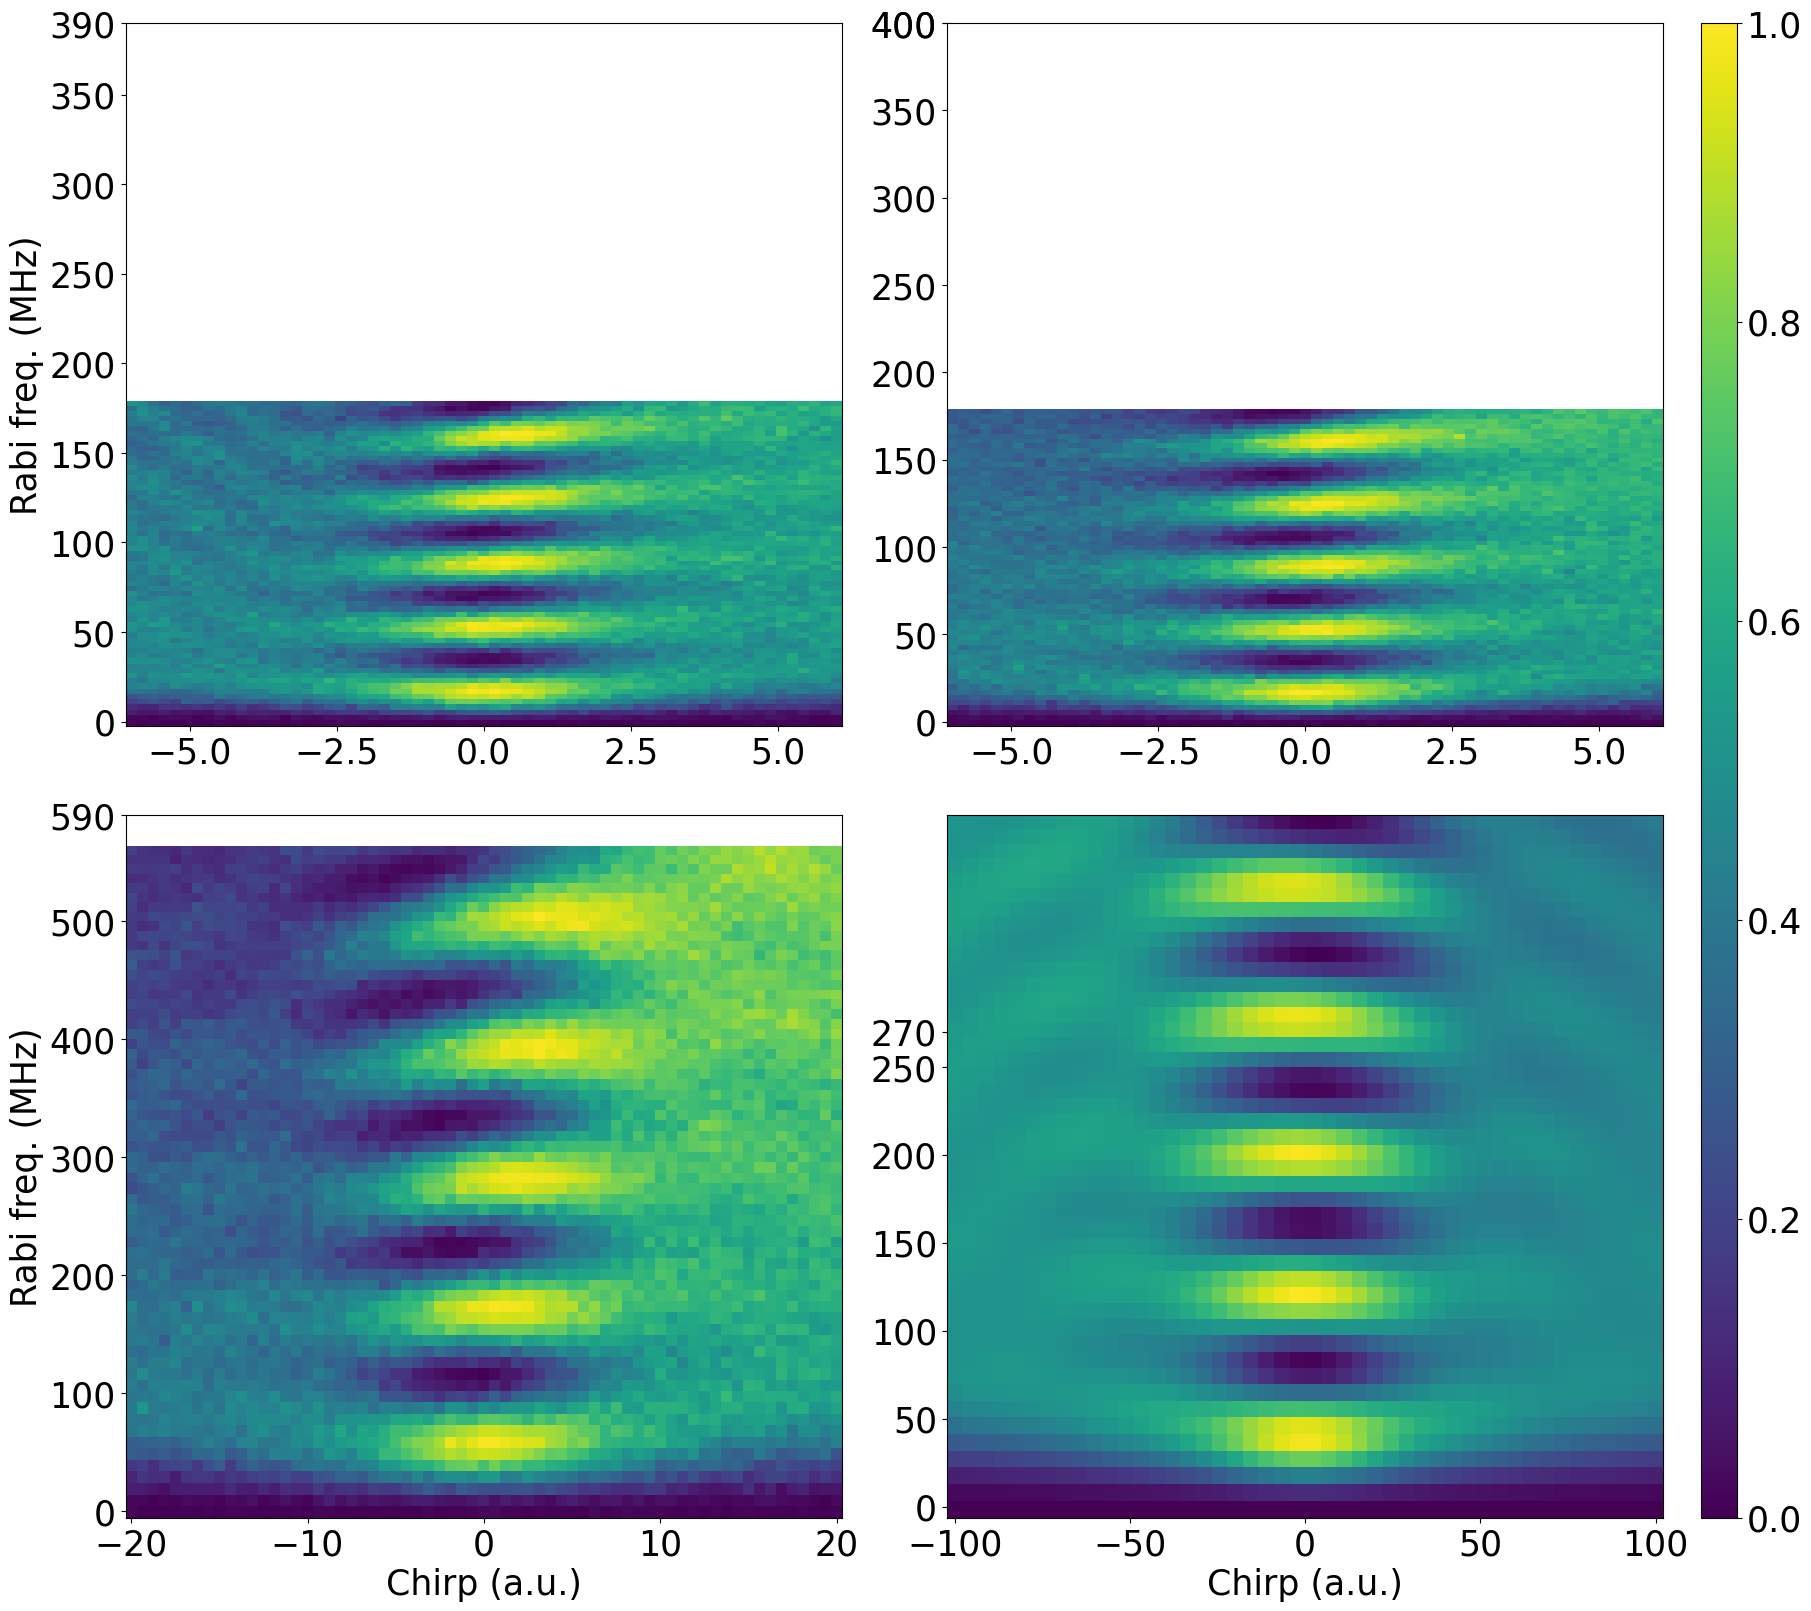

In [13]:
fontsize = 25
ymaxs = [350, 400, 500, 250]
ylast = [390, 400, 590, 270]
num_ys = [8, 9, 6, 6]
fig = plt.figure(figsize=(18, 16), layout="constrained")
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, .05], height_ratios=[1, 1])
cmap = matplotlib.colormaps["viridis"]
for i in range(2):
    for j in range(2):
        idx = 2 * i + j
        ax = fig.add_subplot(gs[i, j])
        c = ax.pcolormesh(dets[idx], amps[idx], tr_probs[idx], cmap=cmap)
        
        # xmin = np.round((dets[i][0] // 5) * 5, 1)
        # xmax = np.round((dets[i][-1] // 5) * 5, 1)
        # num_x = 5
        
        # xticks = np.linspace(xmin, xmax, num_x)
        # xticklabels = np.round(xticks, 1)
        
        ymin = np.round((np.round(amps[idx][0] / 4)) * 4, 1)
        
        yticks = np.linspace(ymin, ymaxs[idx], num_ys[idx])
        yticks = np.append(yticks, ylast[idx])
        yticklabels = np.round(yticks, 1)
        # ax.set_xticks(xticks)
        if i == 1:
            ax.set_xlabel("Chirp (a.u.)", fontsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        ax.xaxis.get_offset_text().set_fontsize(fontsize)
        if j == 0:
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels, fontsize=fontsize)
            ax.set_ylabel("Rabi freq. (MHz)", fontsize=fontsize)
    
        ax.set_yticks(yticks)
        ax.set_yticklabels(np.round(yticklabels.astype(int), 1), fontsize=fontsize)
        c.set_clim(0,1)
cax = fig.add_subplot(gs[:, 2])
cbar = fig.colorbar(c, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
colorbar_ticks = np.round(np.arange(0, 1.01, 0.2),1)
cbar.set_ticks(colorbar_ticks)
plt.savefig(f"C:/Users/Ivo/Documents/{specific_name}/paper_ready_plots/time_dep/LZ_exc_landscapes_new.pdf")

## Allen-Eberly-Hioe models

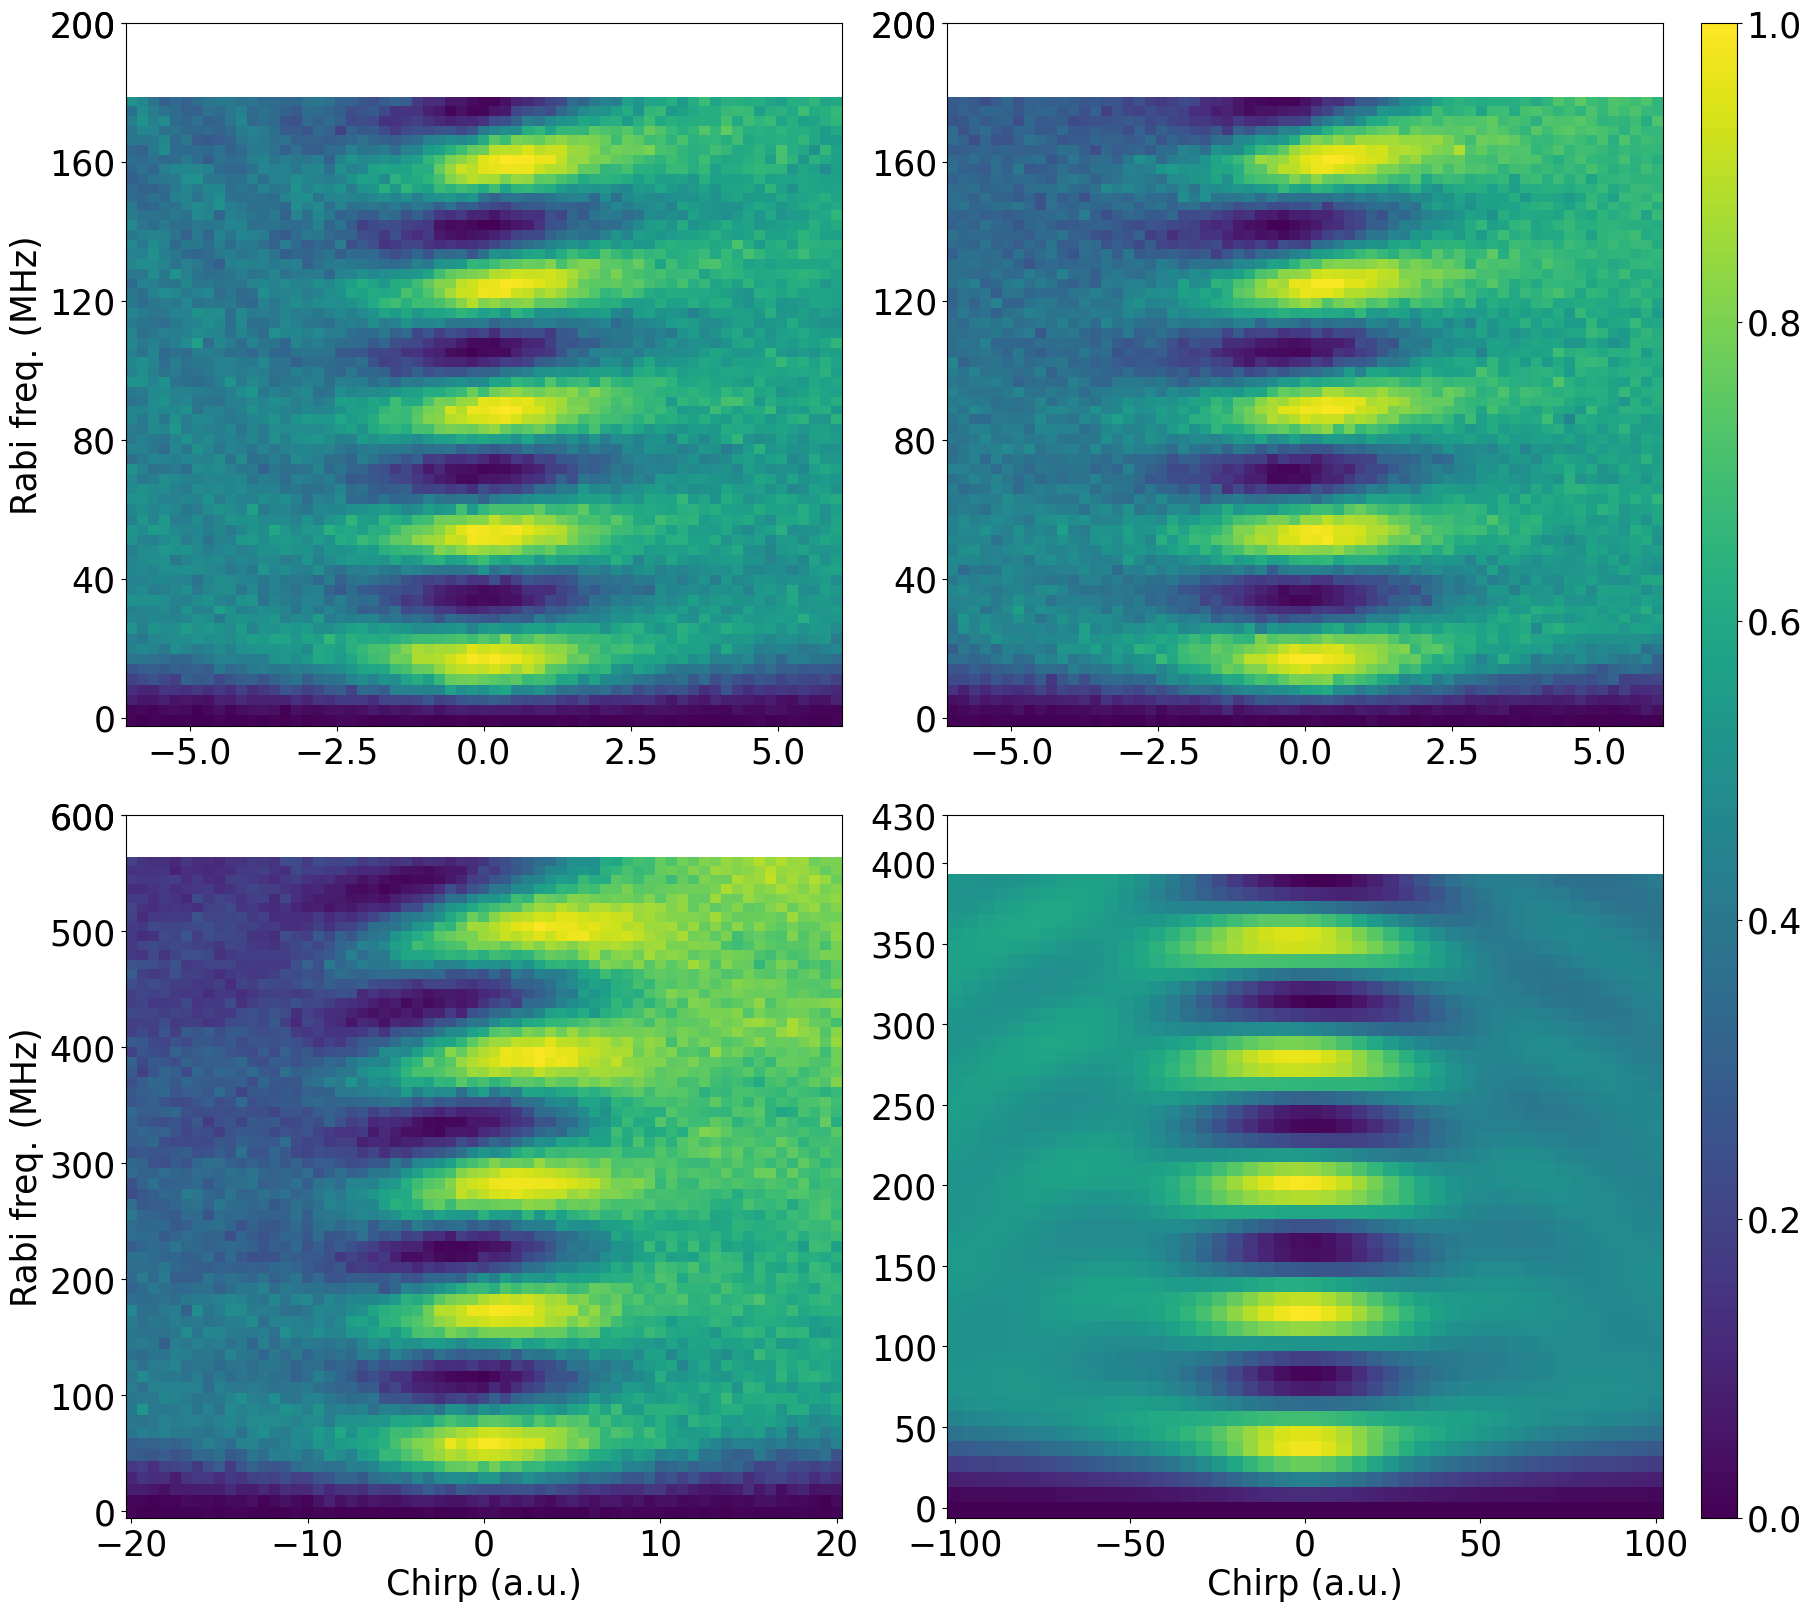

In [14]:
fontsize = 25
ymaxs = [200, 200, 600, 400]
ylast = [200, 200, 600, 430]
num_ys = [6, 6, 7, 9]
fig = plt.figure(figsize=(18,16), layout="constrained")
gs = fig.add_gridspec(2,3, width_ratios=[1, 1, .05])
cmap = matplotlib.colormaps["viridis"]
for i in range(2):
    for j in range(2):
        idx = 2 * i + j
        ax = fig.add_subplot(gs[i,j])
        c = ax.pcolormesh(dets[idx], amps[idx], tr_probs[idx], cmap=cmap)
        
        # xmin = np.round((dets[i][0] // 5) * 5, 1)
        # xmax = np.round((dets[i][-1] // 5) * 5, 1)
        # num_x = 5
        
        # xticks = np.linspace(xmin, xmax, num_x)
        # xticklabels = np.round(xticks, 1)
        
        ymin = np.round((np.round(amps[idx][0] / 4)) * 4, 1)
        
        yticks = np.linspace(ymin, ymaxs[idx], num_ys[idx])
        yticks = np.append(yticks, ylast[idx])
        yticklabels = np.round(yticks, 1)
        # ax.set_xticks(xticks)
        if i == 1:
            ax.set_xlabel("Chirp (a.u.)", fontsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        ax.xaxis.get_offset_text().set_fontsize(fontsize)
        if j == 0:
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels, fontsize=fontsize)
            ax.set_ylabel("Rabi freq. (MHz)", fontsize=fontsize)
    
        ax.set_yticks(yticks)
        ax.set_yticklabels(np.round(yticklabels.astype(int), 1), fontsize=fontsize)
        c.set_clim(0,1)
cax = fig.add_subplot(gs[:, 2])
cbar = fig.colorbar(c, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
colorbar_ticks = np.round(np.arange(0, 1.01, 0.2),1)
cbar.set_ticks(colorbar_ticks)
plt.savefig(f"C:/Users/Ivo/Documents/{specific_name}/paper_ready_plots/time_dep/AE_exc_landscapes_new.pdf")

## half-Allen-Eberly-Hioe Models

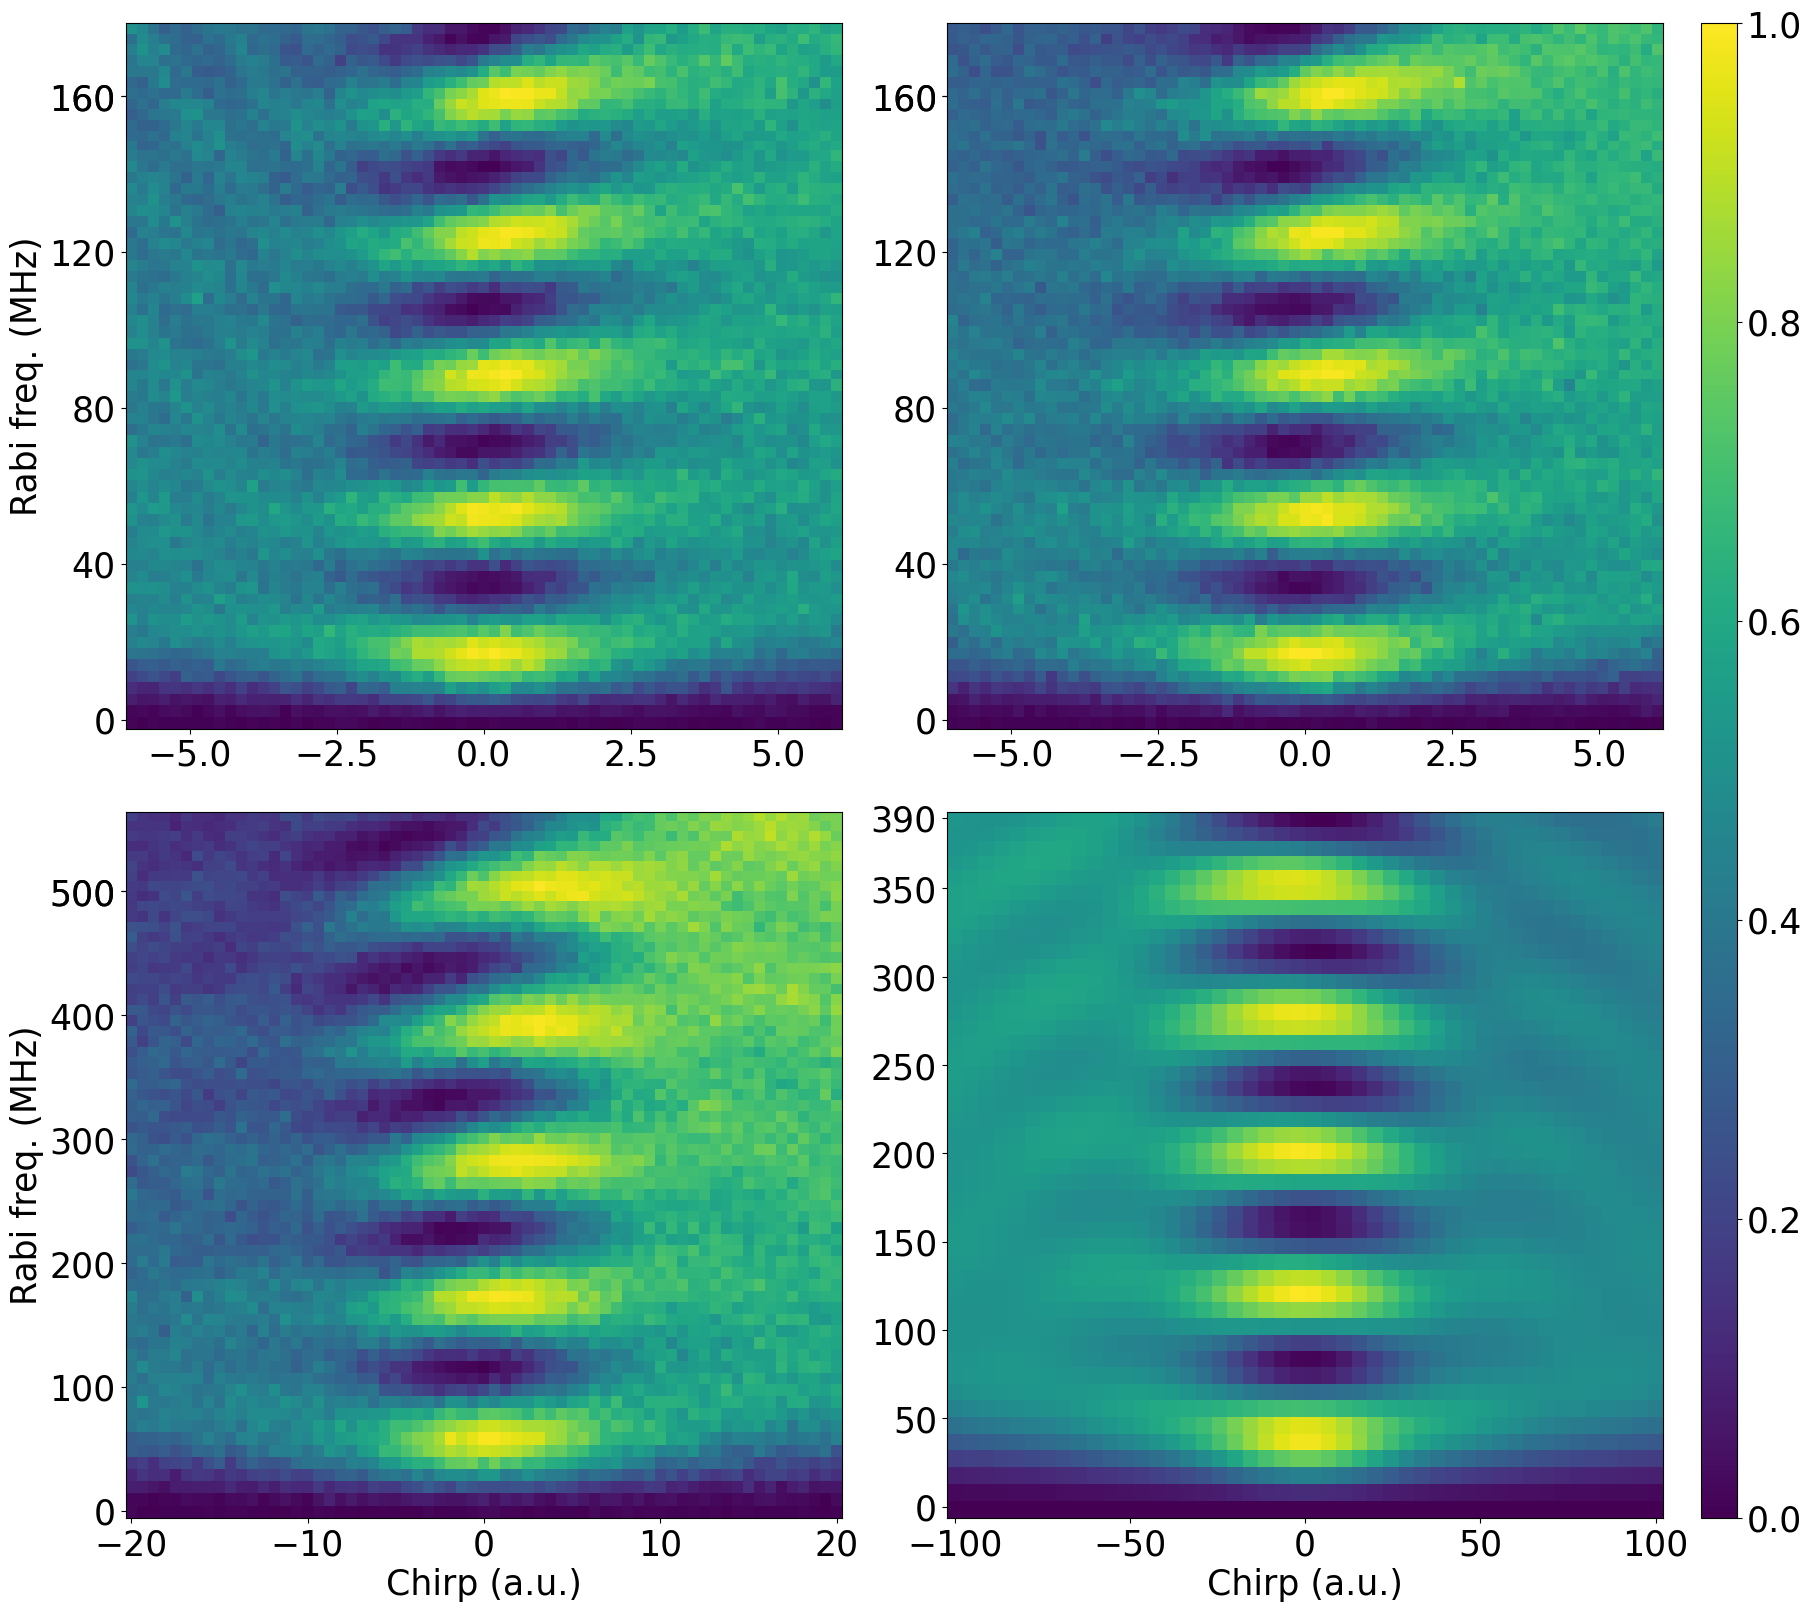

In [15]:
fontsize = 25
ymaxs = [160, 160, 500, 350]
ylast = [160, 160, 500, 390]
num_ys = [5, 5, 6, 8]
fig = plt.figure(figsize=(18, 16), layout="constrained")
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, .05])
cmap = matplotlib.colormaps["viridis"]
for i in range(2):
    for j in range(2):
        idx = 2 * i + j
        ax = fig.add_subplot(gs[i,j])
        c = ax.pcolormesh(dets[idx], amps[idx], tr_probs[idx], cmap=cmap)
        
        # xmin = np.round((dets[i][0] // 5) * 5, 1)
        # xmax = np.round((dets[i][-1] // 5) * 5, 1)
        # num_x = 5
        
        # xticks = np.linspace(xmin, xmax, num_x)
        # xticklabels = np.round(xticks, 1)
        
        ymin = np.round((np.round(amps[idx][0] / 4)) * 4, 1)
        
        yticks = np.linspace(ymin, ymaxs[idx], num_ys[idx])
        yticks = np.append(yticks, ylast[idx])
        yticklabels = np.round(yticks, 1)
        # ax.set_xticks(xticks)
        if i == 1:
            ax.set_xlabel("Chirp (a.u.)", fontsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        ax.xaxis.get_offset_text().set_fontsize(fontsize)
        if j == 0:
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels, fontsize=fontsize)
            ax.set_ylabel("Rabi freq. (MHz)", fontsize=fontsize)
    
        ax.set_yticks(yticks)
        ax.set_yticklabels(np.round(yticklabels.astype(int), 1), fontsize=fontsize)
        c.set_clim(0,1)
cax = fig.add_subplot(gs[:, 2])
cbar = fig.colorbar(c, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
colorbar_ticks = np.round(np.arange(0, 1.01, 0.2),1) 
cbar.set_ticks(colorbar_ticks)
plt.savefig(f"C:/Users/Ivo/Documents/{specific_name}/paper_ready_plots/time_dep/HAE_exc_landscapes_new.pdf")

## Bambini-Berman and CosSin models

In [13]:
# specific_name = "qiskit_codes"
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/data/kyiv/14/power_broadening (narrowing)"

folders = [f"{folder}/bb_pulses/2024-12-30",
           f"{folder}/cs_pulses/2024-12-31"]
times = []
for folder in folders:
    times_folder = [folder + '/' + os.listdir(folder)[-1]]
    times.extend(times_folder)
print(times)


['C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/bb_pulses/2024-12-30/234537', 'C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/cs_pulses/2024-12-31/021519']


In [14]:
# if which_plots in [0, 1]:
#     l, p, x0 = 573.692297386677,0.2271200201666013,0.0012287080262098 # 800
#     T = 800 * 2e-9 / 9 
# elif which_plots == 2:
l, p, x0 = 240.31017602118783,0.273639040773091,0.0020544076252577 # 400
T = 400 * 2e-9 / 9 
tr_probs, dets, amps = [], [], []
for t in times:
    files = os.listdir(t)
    f1 = [f for f in files if f.endswith("tr_prob.pkl")][0]
    f2 = [f for f in files if f.endswith("detunings.pkl")][0]
    f3 = [f for f in files if f.endswith("areas.pkl")][0]
    with open(os.path.join(t, f1), "rb") as f1:
        tr_probs.append(pickle.load(f1))    
    with open(os.path.join(t, f2), "rb") as f2:
        dets.append(pickle.load(f2) / 1e6)   
    with open(os.path.join(t, f3), "rb") as f3:
        amps.append(l * (1 - np.exp(- p * (pickle.load(f3) - x0))) / (1e6 * T))

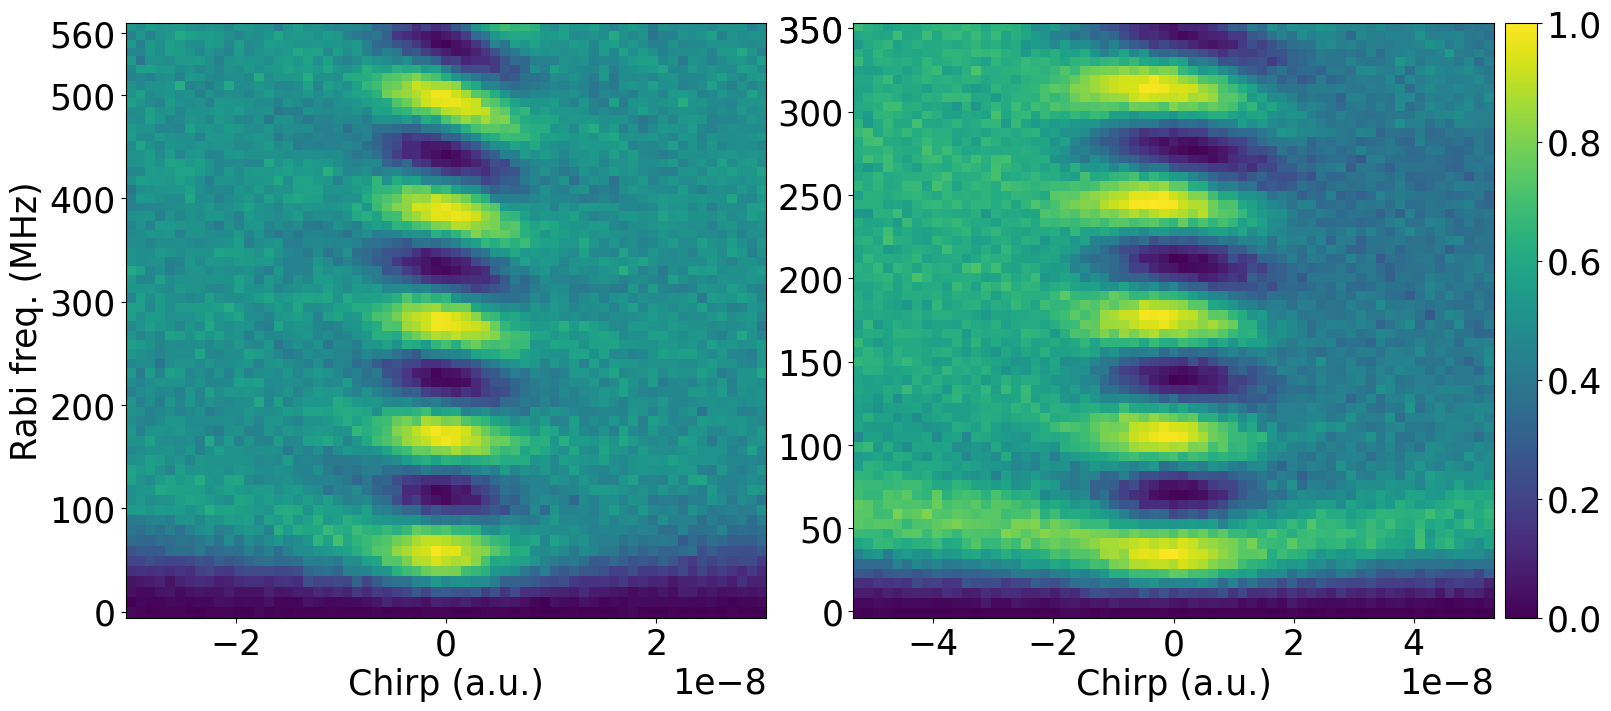

In [15]:
fontsize = 25
ymaxs = [500, 350]
ylast = [560, 350]
num_ys = [6, 8]
fig = plt.figure(figsize=(16,7), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, .05])
cmap = matplotlib.colormaps["viridis"]
for i in range(len(times)):
    ax = fig.add_subplot(gs[0, i])
    c = ax.pcolormesh(dets[i], amps[i], tr_probs[i], cmap=cmap)
    
    # xmin = np.round((dets[i][0] // 5) * 5, 1)
    # xmax = np.round((dets[i][-1] // 5) * 5, 1)
    # num_x = 5
    
    # xticks = np.linspace(xmin, xmax, num_x)
    # xticklabels = np.round(xticks, 1)
    
    ymin = np.round((np.round(amps[i][0] / 4)) * 4, 1)
    
    yticks = np.linspace(ymin, ymaxs[i], num_ys[i])
    yticks = np.append(yticks, ylast[i])
    yticklabels = np.round(yticks, 1)
    # ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelsize=fontsize)
    ax.set_xlabel("Chirp (a.u.)", fontsize=fontsize)
    ax.xaxis.get_offset_text().set_fontsize(fontsize)
    if i == 0:
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=fontsize)
        ax.set_ylabel("Rabi freq. (MHz)", fontsize=fontsize)

    ax.set_yticks(yticks)
    ax.set_yticklabels(np.round(yticklabels.astype(int), 1), fontsize=fontsize)
    c.set_clim(0,1)
cax = fig.add_subplot(gs[:, 2])
cbar = fig.colorbar(c, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
colorbar_ticks = np.round(np.arange(0, 1.01, 0.2),1)
cbar.set_ticks(colorbar_ticks)
plt.savefig(f"C:/Users/Ivo/Documents/{specific_name}/paper_ready_plots/time_dep/BB_CS_exc_landscapes.pdf")